# Lib

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, Birch
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


# Load data

In [9]:
project_root = Path.cwd().parent
file_path = project_root / "data" / "cleaned" / "olist_customers.csv"

df = pd.read_csv(file_path)
print(f"Shape: {df.shape}")
df.head()

Shape: (93354, 17)


,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type,avg_delivery_days,avg_shipping_delay,late_delivery_ratio,avg_freight_ratio,avg_freight_value,avg_estimated_gap
0,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho,1,credit_card,6.0,-5.0,0.0,0.084567,12.00,10.0
1,1,6053,osasco,SP,115,27.19,1,1,beleza_saude,1,credit_card,3.0,-5.0,0.0,0.304892,8.29,7.0
2,1,88115,sao jose,SC,537,86.22,1,1,papelaria,1,credit_card,25.0,-2.0,0.0,0.199722,17.22,27.0
3,1,66812,belem,PA,321,43.62,1,1,telefonia,1,credit_card,20.0,-12.0,0.0,0.404172,17.63,31.0
4,1,18040,sorocaba,SP,288,196.89,1,1,telefonia,1,credit_card,13.0,-8.0,0.0,0.085784,16.89,20.0


# Preprocessing

## Select features

In [10]:
numerical_features = [
    'frequency', 'recency', 'monetary', 'total_item',
    'unique_category', 'payment_type_diversity',
    'avg_delivery_days', 'avg_shipping_delay',
    'late_delivery_ratio', 'avg_freight_ratio',
    'avg_freight_value', 'avg_estimated_gap'
]

X = df[numerical_features].copy()

## Standardize data

In [11]:
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_arr, columns=numerical_features, index=X.index)

## PCA

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f"Explained variance ratio: {explained}")
print(f"Total variance explained: {explained.sum():.4f}")

Explained variance ratio: [0.1861796  0.16970677]
Total variance explained: 0.3559


# Models

## K-Means Clustering

In [13]:
k = 3

In [14]:
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Đánh giá
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"Silhouette Score:       {kmeans_sil:.4f}")
print(f"Calinski-Harabasz Index: {kmeans_ch:.4f}")
print(f"Davies-Bouldin Index:    {kmeans_db:.4f}")
print(f"\nPhân bố cụm:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

Silhouette Score:       0.4441
Calinski-Harabasz Index: 16442.3363
Davies-Bouldin Index:    1.0624

Phân bố cụm:
0     7486
1    83228
2     2640
Name: count, dtype: int64


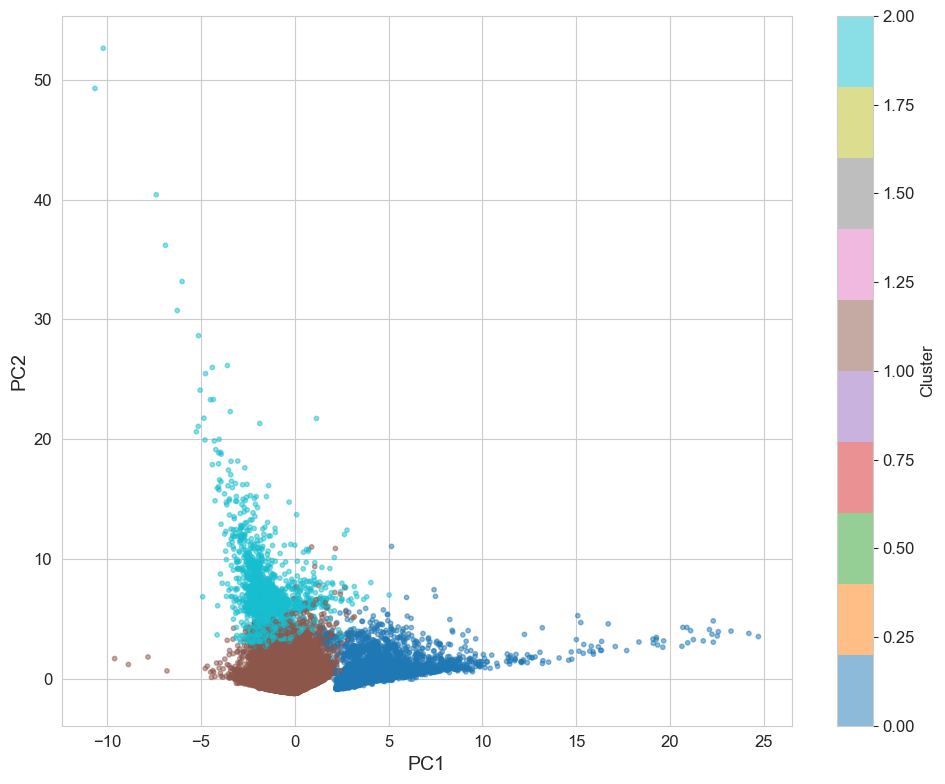

In [15]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                      cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.tight_layout()
plt.show()

## Birch

In [36]:
birch = Birch(n_clusters=k, branching_factor=100)
birch_labels = birch.fit_predict(X_scaled)

birch_sil = silhouette_score(X_scaled, birch_labels)
birch_ch = calinski_harabasz_score(X_scaled, birch_labels)
birch_db = davies_bouldin_score(X_scaled, birch_labels)

print(f"Silhouette Score:        {birch_sil:.4f}")
print(f"Calinski-Harabasz Index: {birch_ch:.4f}")
print(f"Davies-Bouldin Index:    {birch_db:.4f}")
print(f"\nPhân bố cụm:")
print(pd.Series(birch_labels).value_counts().sort_index())

Silhouette Score:        0.4285
Calinski-Harabasz Index: 15504.0928
Davies-Bouldin Index:    0.9761

Phân bố cụm:
0    83920
1     2308
2     7126
Name: count, dtype: int64


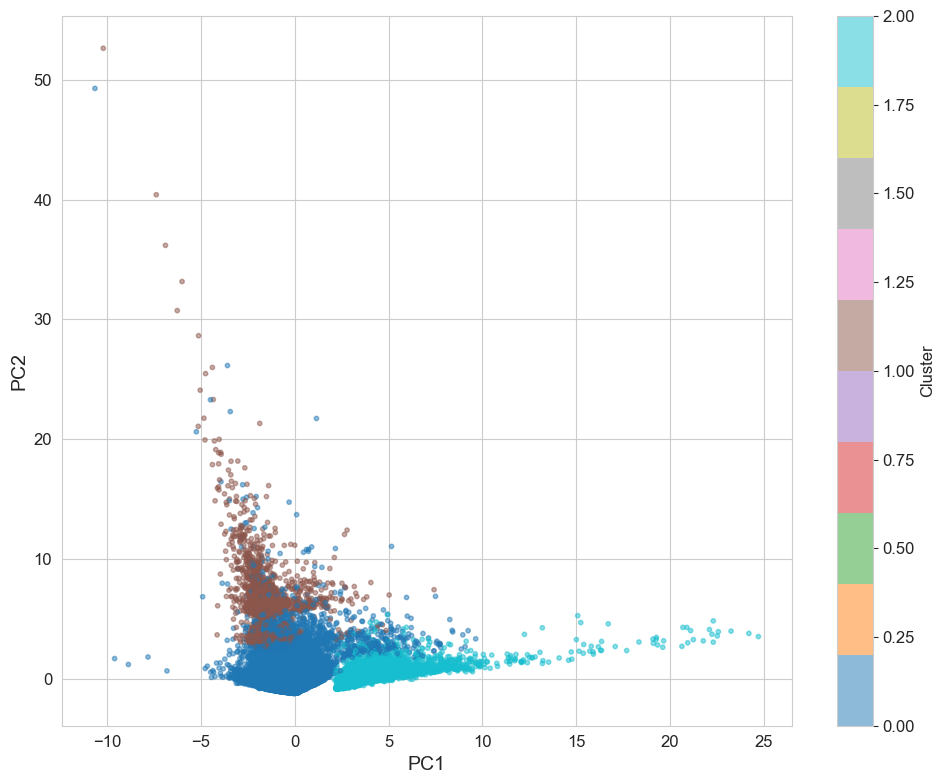

In [37]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=birch_labels,
                      cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.tight_layout()
plt.show()

## MiniBatchKMeans

In [18]:
mbk = MiniBatchKMeans(n_clusters=k, random_state=42)
mbk_labels = mbk.fit_predict(X_scaled)

# Đánh giá
mbk_sil = silhouette_score(X_scaled, mbk_labels)
mbk_ch = calinski_harabasz_score(X_scaled, mbk_labels)
mbk_db = davies_bouldin_score(X_scaled, mbk_labels)

print(f"Silhouette Score:        {mbk_sil:.4f}")
print(f"Calinski-Harabasz Index: {mbk_ch:.4f}")
print(f"Davies-Bouldin Index:    {mbk_db:.4f}")
print(f"\nPhân bố cụm:")
print(pd.Series(mbk_labels).value_counts().sort_index())

Silhouette Score:        0.4441
Calinski-Harabasz Index: 16442.1847
Davies-Bouldin Index:    1.0618

Phân bố cụm:
0    83229
1     7487
2     2638
Name: count, dtype: int64


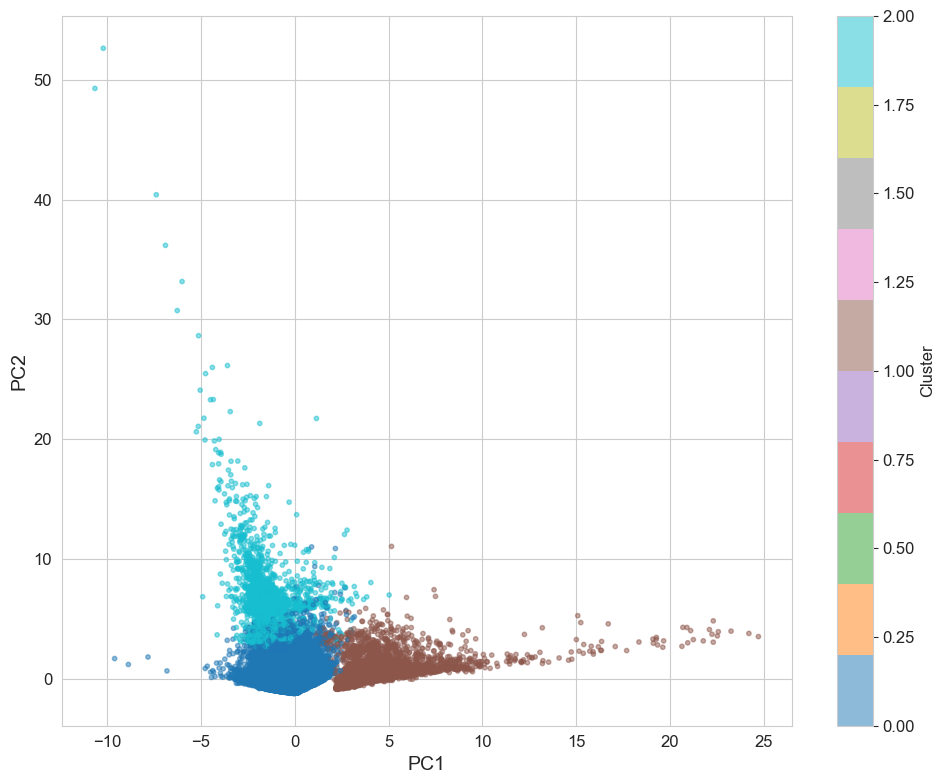

In [19]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=mbk_labels,
                      cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.tight_layout()
plt.show()

# Main

## Compare models

In [38]:
comparison = pd.DataFrame({
    'Model': ['K-Means', 'BIRCH', 'MiniBatchKMeans'],
    'Silhouette Score': [kmeans_sil, birch_sil, mbk_sil],
    'Calinski-Harabasz': [kmeans_ch, birch_ch, mbk_ch],
    'Davies-Bouldin': [kmeans_db, birch_db, mbk_db]
})
print("=== BẢNG SO SÁNH CÁC MÔ HÌNH PHÂN CỤM ===")
print(comparison.to_string(index=False))

=== BẢNG SO SÁNH CÁC MÔ HÌNH PHÂN CỤM ===
          Model  Silhouette Score  Calinski-Harabasz  Davies-Bouldin
        K-Means          0.444063       16442.336263        1.062409
          BIRCH          0.428510       15504.092817        0.976068
MiniBatchKMeans          0.444069       16442.184749        1.061821


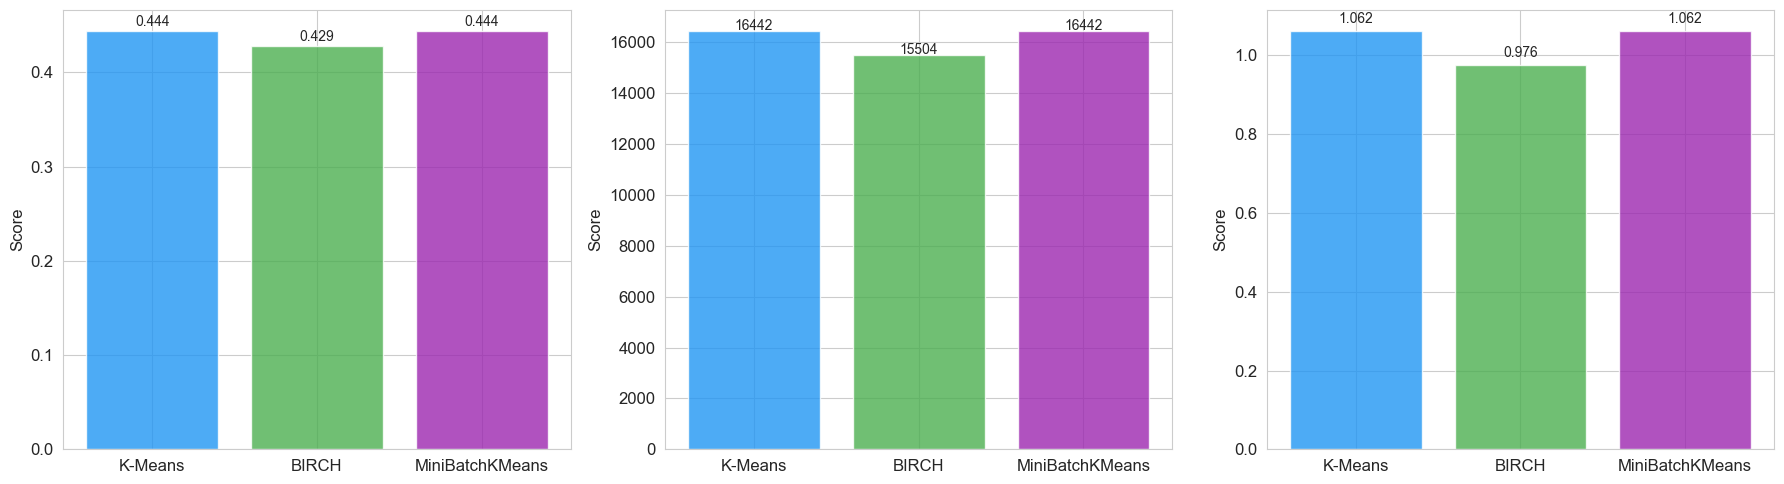

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = ['K-Means', 'BIRCH', 'MiniBatchKMeans']
colors = ['#2196F3', '#4CAF50', '#9C27B0']

axes[0].bar(models, comparison['Silhouette Score'], color=colors, alpha=0.8)
axes[0].set_ylabel('Score')
for i, v in enumerate(comparison['Silhouette Score']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(models, comparison['Calinski-Harabasz'], color=colors, alpha=0.8)
axes[1].set_ylabel('Score')
for i, v in enumerate(comparison['Calinski-Harabasz']):
    axes[1].text(i, v + 50, f'{v:.0f}', ha='center', fontsize=10)

axes[2].bar(models, comparison['Davies-Bouldin'], color=colors, alpha=0.8)
axes[2].set_ylabel('Score')
for i, v in enumerate(comparison['Davies-Bouldin']):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Cluster analysis

In [40]:
df_clustered = df.loc[X.index].copy()
df_clustered['cluster'] = kmeans_labels

cluster_profile = df_clustered.groupby('cluster')[numerical_features].mean()
cluster_profile.round(2)

,frequency,recency,monetary,total_item,unique_category,payment_type_diversity,avg_delivery_days,avg_shipping_delay,late_delivery_ratio,avg_freight_ratio,avg_freight_value,avg_estimated_gap
cluster,,,,,,,,,,,,
0,1.01,215.53,174.70,1.16,1.00,1.02,31.09,8.87,1.00,0.21,22.42,21.64
1,1.01,240.82,158.99,1.18,1.00,1.02,10.43,-13.65,0.00,0.21,20.01,23.49
2,1.84,210.32,333.89,3.18,1.91,1.18,10.88,-13.70,0.05,0.22,19.49,23.97


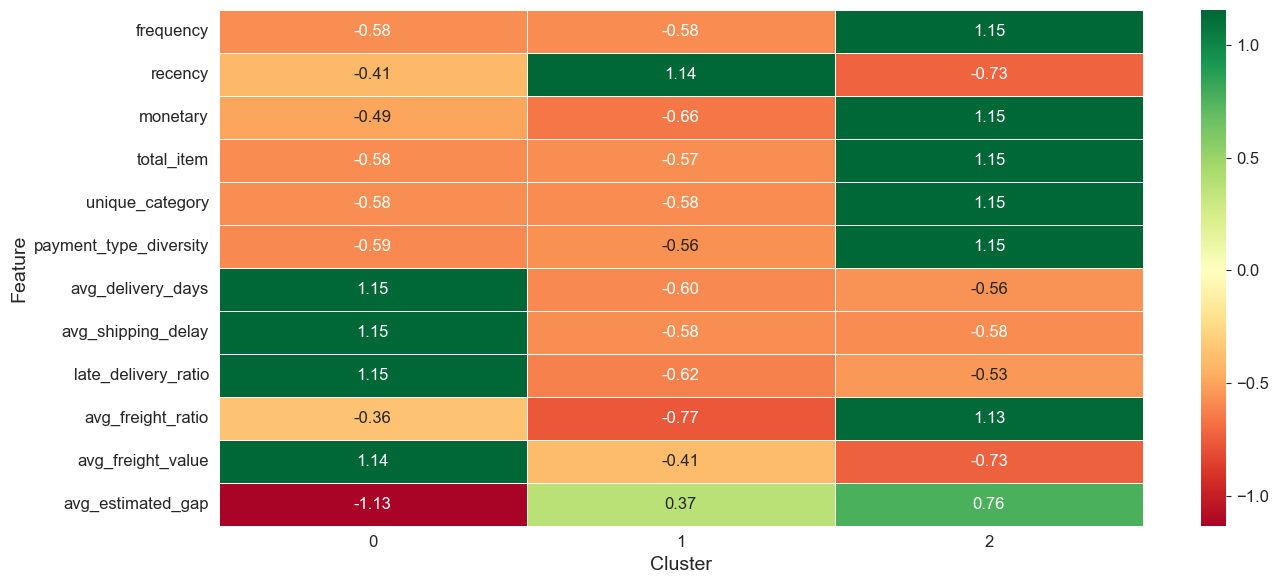

In [41]:
plt.figure(figsize=(14, 6))
profile_scaled = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
sns.heatmap(profile_scaled.T, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5)
plt.xlabel('Cluster', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.tight_layout()
plt.show()

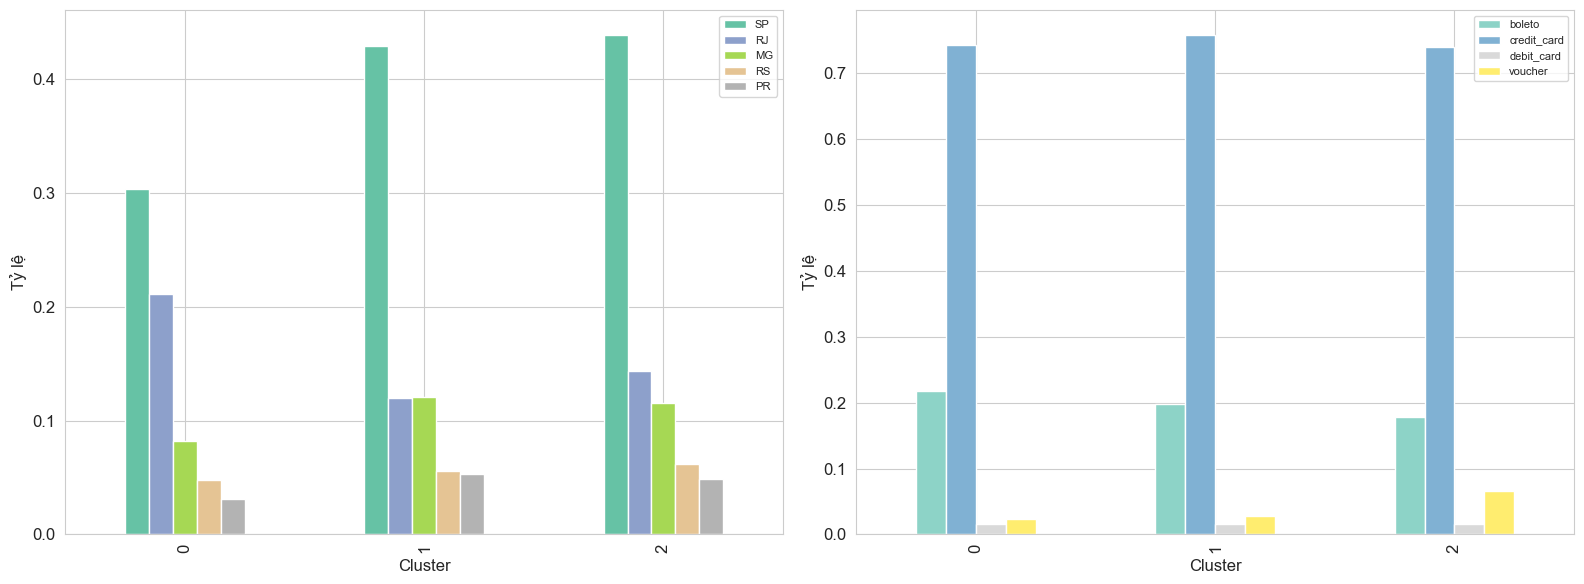

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ct = pd.crosstab(df_clustered['cluster'], df_clustered['customer_state'], normalize='index')
top_states = df_clustered['customer_state'].value_counts().head(5).index
ct[top_states].plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Tỷ lệ')
axes[0].legend(fontsize=8)

ct2 = pd.crosstab(df_clustered['cluster'], df_clustered['dominant_payment_type'], normalize='index')
ct2.plot(kind='bar', ax=axes[1], colormap='Set3')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Tỷ lệ')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

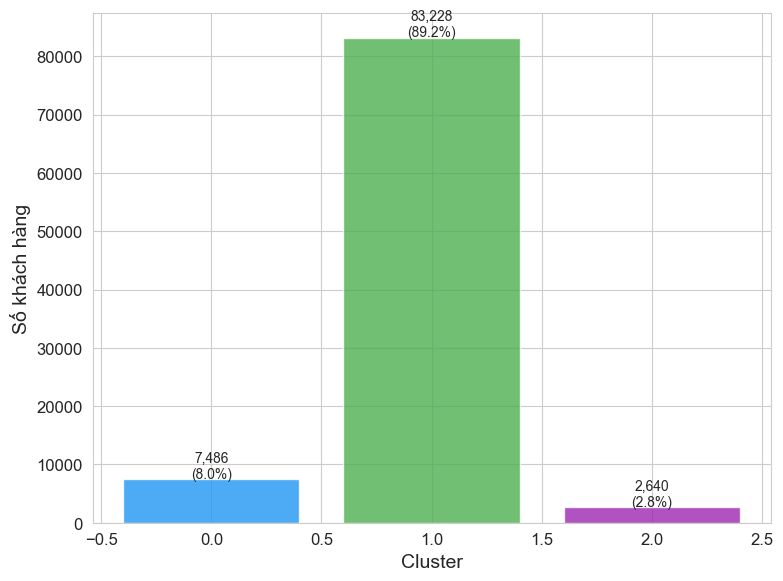

In [43]:
plt.figure(figsize=(8, 6))
cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()
bars = plt.bar(cluster_sizes.index, cluster_sizes.values, color=colors[:k], alpha=0.8)
for bar, val in zip(bars, cluster_sizes.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 200,
             f'{val:,}\n({val/len(kmeans_labels)*100:.1f}%)',
             ha='center', fontsize=10)
plt.xlabel('Cluster', fontsize=14)
plt.ylabel('Số khách hàng', fontsize=14)
plt.tight_layout()
plt.show()

# I/O

## Path

In [45]:
import joblib
import os

model_dir = project_root / "models"
os.makedirs(model_dir, exist_ok=True)

KMEANS_PATH = model_dir / 'kmeans_model.pkl'
BIRCH_PATH = model_dir / 'birch_model.pkl'
MBK_PATH = model_dir / 'minibatch_kmeans_model.pkl'
SCALER_PATH = model_dir / 'scaler.pkl'
PCA_PATH = model_dir / 'pca.pkl'

## Save model

In [46]:
joblib.dump(kmeans, KMEANS_PATH)
joblib.dump(birch, BIRCH_PATH)
joblib.dump(mbk, MBK_PATH)

joblib.dump(scaler, SCALER_PATH)
joblib.dump(pca, PCA_PATH)

print(f"Các mô hình đã được lưu tại: {model_dir}")

Các mô hình đã được lưu tại: c:\Users\HP\Documents\data-mining-project\models


## Load model

In [47]:
# Load models
loaded_kmeans = joblib.load(KMEANS_PATH)
loaded_birch = joblib.load(BIRCH_PATH)
loaded_mbk = joblib.load(MBK_PATH)

loaded_scaler = joblib.load(SCALER_PATH)
loaded_pca = joblib.load(PCA_PATH)